# Lab: Deep Learning MLP with PyTorch

* Author: geoffroy.peeters@telecom-paris.fr
* Date: 2026-02-18

The goal of the Lab is to use (train and test) an MLP for a multi-class classification task on real data.

You will
- download the data from the internet.
- process the data using Pandas:
    - load the .xls file, split into X and y, split into train and eval-set.
- create a pytorch Dataset to allow getting them on the fly.
- write an MLP model using the `nn.Module` class formalism.
- write a loop over epochs in wich you train the model over mini-batch of the training-set and evaluate over the eval-set.
    - display at each epoch the losses and accuracies over training and test data.
- plot the losses and accuracies evoluation over epochs.

You will use the 'Dry Bean Dataset' descibed here https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset and downloadable here https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip.

## Your tasks
- 1) Fill-in the missing part
- 2) Correct the error mades in the text and in the provided code


# Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import urllib.request

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Data acquisition

Get the Dry Bean Dataset

Documentation: https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset

URL: https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip

In [2]:
!rm DryBeanDataset.zip
!rm -rf ./DryBeanDataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip"
urllib.request.urlretrieve(url, "DryBeanDataset.zip")

!unzip DryBeanDataset.zip

'rm' is not recognized as an internal or external command,
operable program or batch file.
'rm' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


# Data preprocessing (using pandas and sklearn)

Process the data
* load the .xls file data using `pandas` (read_excel)
* split into X (all columns except `Class`) and y (column `Class`) using `pandas`
* convert y to integer using `sklearn` (LabelEncoder)
* split into train and valid datasets using `sklearn` (train_test_split), we use a 80\% train, 20\% validation split
* standardize the X of train and valid using `sklearn` (StandardScaler)



In [4]:
def load_and_preprocess(data_file):
    df = pd.read_excel(data_file)
    X = df.drop(columns=['Class']).values
    y = df['Class'].values
    # Encode labels
    le = LabelEncoder()
    y = le.fit_transform(y)
    # Split into train and validation sets
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    # Standardize features 
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)
    return X_train, X_valid, y_train, y_valid, len(np.unique(y))

data_file = 'DryBeanDataset/Dry_Bean_Dataset.xlsx'
X_train, X_valid, y_train, y_valid, num_classes = load_and_preprocess(data_file)

In [5]:
print(X_train.shape)
print(y_train.shape)
print(set(y_train))

print(X_valid.shape)
print(y_valid.shape)
print(set(y_valid))

(10888, 16)
(10888,)
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}
(2723, 16)
(2723,)
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}


# Write the pytorch Dataset and Dataloader

create a pytorch Dataset to allow getting X and y on the fly
* we need to convert the data from numpy to torch-tensors

In [12]:
# --- 2
class BeanDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)


    def __len__(self):
        return len(self.X)
    

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

train_dataset = BeanDataset(X_train, y_train)
valid_dataset = BeanDataset(X_valid, y_valid)

# DataLoaders handle batching, shuffling, and multi-process loading.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

# Write the MLP model using `nn.Module`

The MLP model as the following architecture: `input_dim -> 128 -> 64 -> 64 -> output_dim`
* `output_dim`corresponds to the number of classes
* we put a `ReLU` between each layer
* we use a `softmax` activation at the end (since we deal with a multi-class problem)

In [18]:
# --- 3
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(X_train.shape[1], num_classes).to(device)

# Define the loss to be minimized and the optimizer

We use a loss named `MSE` since we deal multi-class classification.

We optimize the model using an `Adam` optimizer using a learning rate of 0.001.

In [19]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Write the main loop

We write the main loop over epochs.
For each epoch
* we train the model
    * we set the model in train mode using `model.train()`
    * we loop over mini-batches of training data: zero_grad(), forward, loss, backward, step
    * we compute the current accuracy
* we evaluate the currently trained model on the validation data
    * we set the model in train mode using `model.eval()`
    * we loop over mini-batches of validation data: forward, loss
    * we compute the current loss and accuracy
* we store and print the loss and accuracy for training and validation data

In [24]:
epochs = 100
history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}

# --- 4
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, nn.functional.one_hot(y_batch, num_classes=num_classes).float())
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()
    
    avg_train_loss = train_loss / total_train
    train_acc = correct_train / total_train
    
    model.eval()
    valid_loss = 0.0
    correct_valid = 0
    total_valid = 0
    
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, nn.functional.one_hot(y_batch, num_classes=num_classes).float())
            valid_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_valid += y_batch.size(0)
            correct_valid += (predicted == y_batch).sum().item()
    
    avg_valid_loss = valid_loss / total_valid
    valid_acc = correct_valid / total_valid
    
    history['train_loss'].append(avg_train_loss)
    history['valid_loss'].append(avg_valid_loss)
    history['train_acc'].append(train_acc)
    history['valid_acc'].append(valid_acc)
    
    print(f'Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Valid Loss: {avg_valid_loss:.4f}, Valid Acc: {valid_acc:.4f}')

Epoch 1/100 - Train Loss: 0.0116, Train Acc: 0.9483, Valid Loss: 0.0163, Valid Acc: 0.9258
Epoch 2/100 - Train Loss: 0.0115, Train Acc: 0.9484, Valid Loss: 0.0162, Valid Acc: 0.9254
Epoch 3/100 - Train Loss: 0.0116, Train Acc: 0.9480, Valid Loss: 0.0160, Valid Acc: 0.9284
Epoch 4/100 - Train Loss: 0.0115, Train Acc: 0.9475, Valid Loss: 0.0162, Valid Acc: 0.9273
Epoch 5/100 - Train Loss: 0.0116, Train Acc: 0.9480, Valid Loss: 0.0162, Valid Acc: 0.9302
Epoch 6/100 - Train Loss: 0.0116, Train Acc: 0.9488, Valid Loss: 0.0164, Valid Acc: 0.9266
Epoch 7/100 - Train Loss: 0.0115, Train Acc: 0.9479, Valid Loss: 0.0164, Valid Acc: 0.9291
Epoch 8/100 - Train Loss: 0.0116, Train Acc: 0.9482, Valid Loss: 0.0165, Valid Acc: 0.9240
Epoch 9/100 - Train Loss: 0.0115, Train Acc: 0.9480, Valid Loss: 0.0168, Valid Acc: 0.9229
Epoch 10/100 - Train Loss: 0.0115, Train Acc: 0.9481, Valid Loss: 0.0166, Valid Acc: 0.9254
Epoch 11/100 - Train Loss: 0.0116, Train Acc: 0.9479, Valid Loss: 0.0161, Valid Acc: 0.92

# Plot the loss and accuracy evolution over epoches for train and test data

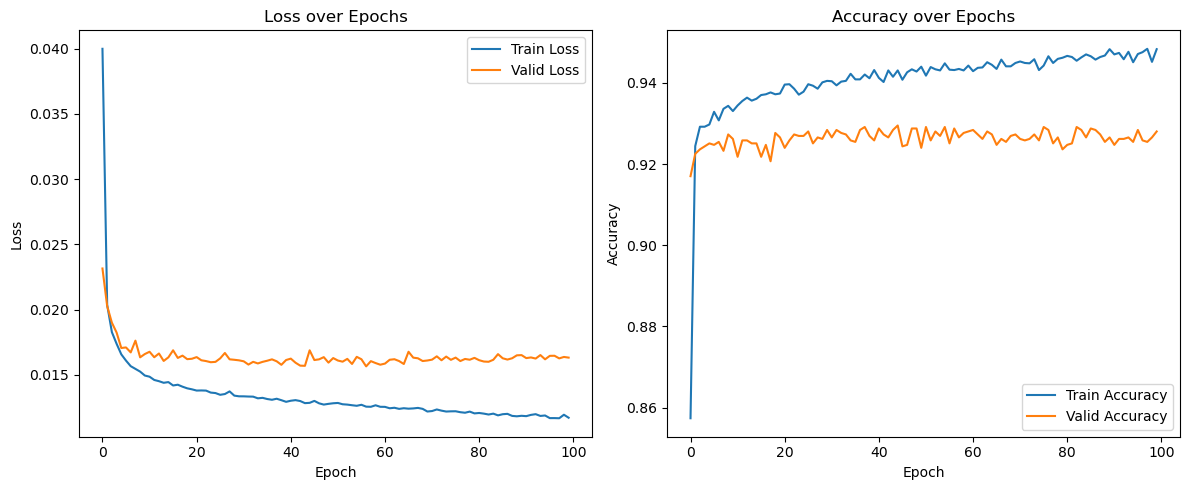

In [23]:
# --- 5
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['valid_loss'], label='Valid Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['valid_acc'], label='Valid Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Early-stopping

In the above, we start doing over-fitting (the loss still decreases for the training data but starts increasing for the validation data). We should stop before this. This is named **early-stopping**. Write a test in the training loop which stop the training when the validation-loss starts increasing.

In [22]:
# --- 6
# Evaluate final model on validation set
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in valid_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

print(f'Validation Accuracy: {100 * correct / total:.2f}%')

Validation Accuracy: 92.80%


# Correction (to be done during peer-grading)

During the peer-grading phase, you will note the lab over 10.

- 6 parts are to be filled-in (# --- 1/2/3/4/5/6). You will assign 1 point for each part (the code should be correct and you should be able to run it).
- 2 errors have been introduced in the text and/or provided-code. You will assign 1 point for each error found
- If the whole code run and provides the loss/epoch and accuracy/epoch curves given above (which involves writing the code and correcting the errors), you will give an extra 2 points.